#6CS012 – Worksheet 5
##Implementation of an End-to-End CNN Model for Image Classification Using Keras

#Objective

In this exercise, we build and train a Convolutional Neural Network (CNN) to classify Amazon fruit images using TensorFlow and Keras. The workflow includes dataset preparation, image visualization, corrupted-image checking, preprocessing, model building, training, evaluation, saving/loading the model, and generating a classification report.

#Task 1: Data Understanding and Visualization
##1.1 Mount Google Drive, Extract the Dataset, and Load Class Names

In [ ]:
# ============================================================
# STEP 1: MOUNT GOOGLE DRIVE, EXTRACT DATASET, AND LOAD CLASSES
# ============================================================

# Import required libraries
from google.colab import drive
import zipfile
import os

# Mount Google Drive so Colab can access files stored in Drive
drive.mount('/content/drive')

# Path to the ZIP file inside Google Drive
zip_path = "/content/drive/MyDrive/Artifical Intelligence and Machine Learning/Dataset/FruitinAmazon.zip"

# Folder where the ZIP file will be extracted in Colab
extract_path = "/content/FruitinAmazon"

# Create the extraction folder if it does not already exist
os.makedirs(extract_path, exist_ok=True)

# Extract all contents of the ZIP file into the extraction folder
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully.")

# Show what was extracted
print("Extracted content:", os.listdir(extract_path))

# If train and test are directly inside extract_path, use it
# Otherwise, use the inner 'FruitinAmazon' folder
if "train" in os.listdir(extract_path) and "test" in os.listdir(extract_path):
    DATASET_DIR = extract_path
else:
    DATASET_DIR = os.path.join(extract_path, "FruitinAmazon")

# Define training and testing folder paths
train_dir = os.path.join(DATASET_DIR, "train")
test_dir = os.path.join(DATASET_DIR, "test")

# Verify that the paths exist and are directories
print("Train directory:", train_dir)
print("Test directory :", test_dir)
print("Train exists   :", os.path.exists(train_dir))
print("Test exists    :", os.path.exists(test_dir))
print("Train is folder:", os.path.isdir(train_dir))
print("Test is folder :", os.path.isdir(test_dir))

# Read all class folders from the training directory
class_names = sorted([
    folder_name
    for folder_name in os.listdir(train_dir)
    if os.path.isdir(os.path.join(train_dir, folder_name))
])

# Print the detected class names
print("Classes found in training data:")
print(class_names)

# Print total number of classes
print("Number of classes:", len(class_names))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset extracted successfully.
Extracted content: ['FruitinAmazon']
Train directory: /content/FruitinAmazon/FruitinAmazon/train
Test directory : /content/FruitinAmazon/FruitinAmazon/test
Train exists   : True
Test exists    : True
Train is folder: True
Test is folder : True
Classes found in training data:
['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Number of classes: 6


##1.2 Count the Number of Images in Each Class
**Explanation**

This step helps us understand how many training images are available in each class folder.

In [ ]:
# ============================================
# STEP 2: COUNT IMAGES IN EACH TRAINING CLASS
# ============================================

# Loop through each class folder
for class_name in class_names:

    # Path to the class folder
    class_path = os.path.join(train_dir, class_name)

    # Count image files in the folder
    image_count = len([
        file_name for file_name in os.listdir(class_path)
        if file_name.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp"))
    ])

    print(f"{class_name}: {image_count} training images")

acai: 15 training images
cupuacu: 15 training images
graviola: 15 training images
guarana: 15 training images
pupunha: 15 training images
tucuma: 15 training images


##1.3 Display One Random Image from Each Class
**Explanation**

The worksheet asks to:

* get the list of class folders from
the train directory
* choose one image randomly from each class
* display them in a grid with two rows

That is exactly what this code does. On page 12, the worksheet’s example shows six fruit classes arranged across two rows.

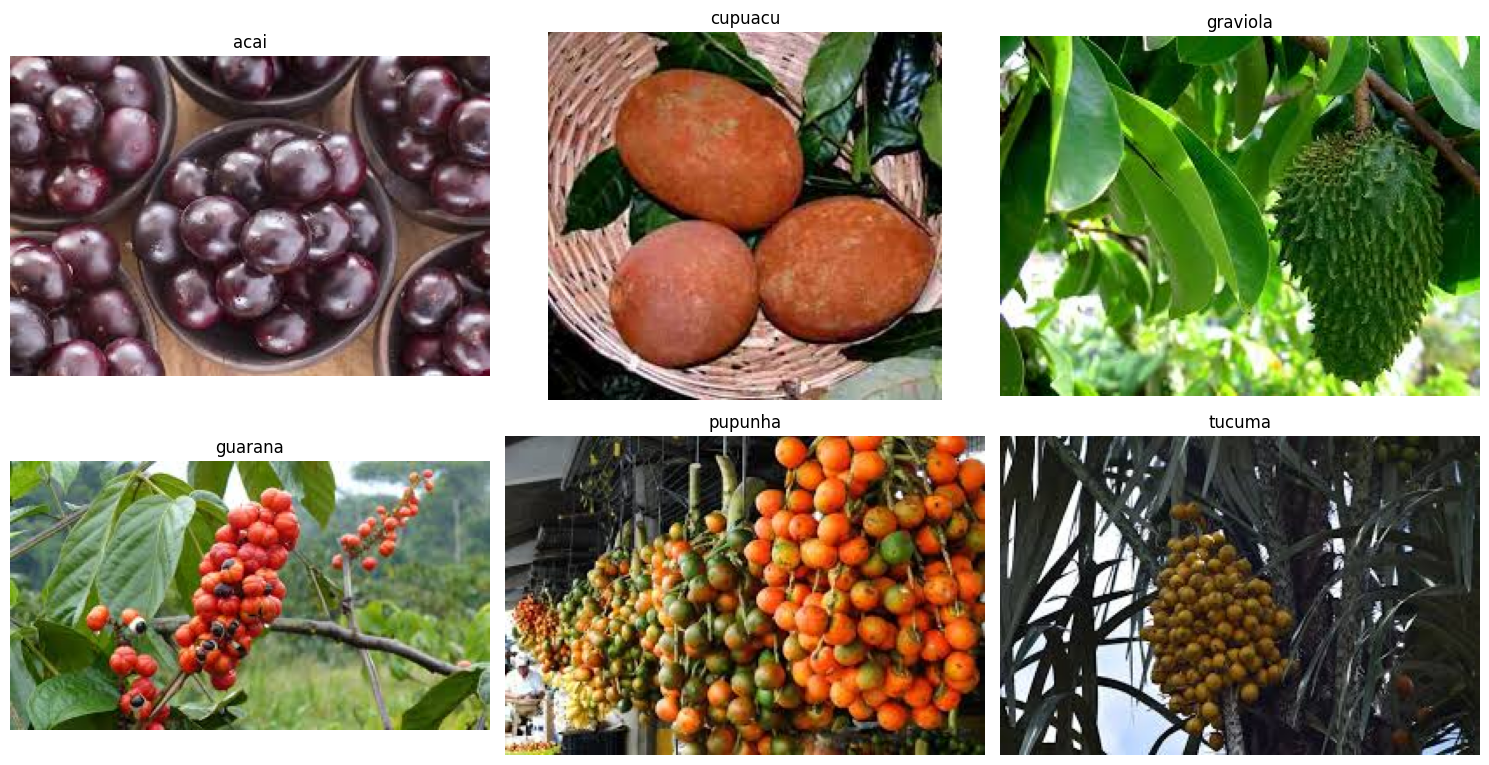

In [ ]:
# ======================================================
# STEP 3: DISPLAY ONE RANDOM IMAGE FROM EACH CLASS
# ======================================================

# Import libraries for image display
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# We want the output arranged in two rows
rows = 2

# Number of columns depends on number of classes
cols = int(np.ceil(len(class_names) / rows))

# Create a figure large enough to show all images clearly
plt.figure(figsize=(15, 8))

# Loop through each class
for i, class_name in enumerate(class_names):

    # Build path to the class folder
    class_path = os.path.join(train_dir, class_name)

    # Get all image files in the current class
    image_files = [
        file_name for file_name in os.listdir(class_path)
        if file_name.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp"))
    ]

    # Select one image randomly from the class folder
    random_image = random.choice(image_files)

    # Build full path to the selected image
    image_path = os.path.join(class_path, random_image)

    # Open the image
    img = Image.open(image_path)

    # Create a subplot for the image
    plt.subplot(rows, cols, i + 1)

    # Show the image
    plt.imshow(img)

    # Display the class name as the title
    plt.title(class_name)

    # Hide axis values for cleaner presentation
    plt.axis("off")

# Automatically adjust spacing between subplots
plt.tight_layout()

# Show the final grid of images
plt.show()

##1.5 Check for Corrupted Images

**Explanation**

The worksheet asks to verify whether the training images are valid and remove corrupted ones if found. On page 13, it suggests using Image.open() and removing any file that raises an error.

In [ ]:
# ======================================================
# STEP 4: CHECK AND REMOVE CORRUPTED TRAINING IMAGES
# ======================================================

# List to store corrupted image paths
corrupted_images = []

# Loop through each class folder
for class_name in class_names:

    # Path to the class folder
    class_path = os.path.join(train_dir, class_name)

    # Loop through each file in the current class folder
    for file_name in os.listdir(class_path):

        # Build full path to the image
        image_path = os.path.join(class_path, file_name)

        # Skip if the path is not a file
        if not os.path.isfile(image_path):
            continue

        try:
            # Try opening the image
            with Image.open(image_path) as img:
                # verify() checks whether the image is valid
                img.verify()

        except (IOError, SyntaxError, OSError):
            # If an error occurs, the image is considered corrupted
            corrupted_images.append(image_path)

            # Remove the corrupted image
            os.remove(image_path)

            # Print the removed file path
            print(f"Removed corrupted image: {image_path}")

# Final result message
if len(corrupted_images) == 0:
    print("No Corrupted Images Found.")
else:
    print(f"Total corrupted images removed: {len(corrupted_images)}")

No Corrupted Images Found.


#Task 2: Loading and Preprocessing Image Data in Keras
##2.1 Import TensorFlow and Define Image Parameters
**Explanation**

The worksheet uses image_dataset_from_directory() for loading images and suggests resizing, batching, and normalization. It also shows an example using image_size=(128,128) and validation split.

In [ ]:
# ======================================================
# STEP 5: IMPORT TENSORFLOW AND DEFINE PARAMETERS
# ======================================================

# Import TensorFlow
import tensorflow as tf

# Define image size
# Every image will be resized to 128x128 pixels
img_height = 128
img_width = 128

# Batch size required by the worksheet for training
batch_size = 16

# Use 20% of training data for validation
validation_split = 0.2

# Random seed for reproducibility
seed = 123

##2.2 Load Training and Validation Datasets
**Explanation**

This code loads images directly from the folder structure:

train/

class_1/

class_2/
...

Keras automatically assigns labels based on folder names.

In [ ]:
# ======================================================
# STEP 6: LOAD TRAINING AND VALIDATION DATASETS
# ======================================================

# Create the training dataset from the training directory
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,                          # Folder containing class subfolders
    labels="inferred",                  # Labels are inferred from folder names
    label_mode="int",                   # Labels will be integer encoded
    image_size=(img_height, img_width), # Resize all images to 128x128
    batch_size=batch_size,              # Number of images per batch
    shuffle=True,                       # Shuffle training data
    validation_split=validation_split,  # Reserve 20% for validation
    subset="training",                  # Load the training portion only
    seed=seed
)

# Create the validation dataset from the same training directory
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="int",
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False,                      # Validation data does not need shuffling
    validation_split=validation_split,
    subset="validation",                # Load the validation portion
    seed=seed
)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.


##2.3 Load the Test Dataset
**Explanation**

The worksheet later asks to evaluate the model on the test set, so we load the test folder separately.

In [ ]:
# ======================================================
# STEP 7: LOAD TEST DATASET
# ======================================================

# Create test dataset from the test directory
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels="inferred",
    label_mode="int",
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False
)

# Print class names recognized by Keras
print("Class names recognized by Keras:")
print(train_ds.class_names)

Found 30 files belonging to 6 classes.
Class names recognized by Keras:
['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


##2.4 Normalize Image Pixel Values
**Explanation**

Images usually have pixel values in the range 0 to 255.
Neural networks train better when values are scaled to 0 to 1.
The worksheet also demonstrates normalization using Rescaling(1./255)

In [ ]:
# ======================================================
# STEP 8: NORMALIZE IMAGE PIXEL VALUES
# ======================================================

# Create a rescaling layer
# It divides every pixel value by 255
rescale = tf.keras.layers.Rescaling(1.0 / 255)

# Apply normalization to training dataset
train_ds = train_ds.map(lambda x, y: (rescale(x), y))

# Apply normalization to validation dataset
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

# Apply normalization to test dataset
test_ds = test_ds.map(lambda x, y: (rescale(x), y))

#2.5 Improve Data Pipeline Performance
**Explanation**

prefetch() helps prepare the next batch while the model is training on the current one.
This improves input pipeline speed.

In [ ]:
# ======================================================
# STEP 9: IMPROVE DATA LOADING PERFORMANCE
# ======================================================

# AUTOTUNE allows TensorFlow to decide the best prefetch size automatically
AUTOTUNE = tf.data.AUTOTUNE

# Prefetch data for better training performance
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

##2.6 Inspect One Batch of Data
**Explanation**

This is a useful checking step to confirm the shape of images and labels after loading.

In [ ]:
# ======================================================
# STEP 10: INSPECT ONE BATCH OF DATA
# ======================================================

# Take one batch from training data and inspect its shape
for images, labels in train_ds.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)

Image batch shape: (16, 128, 128, 3)
Label batch shape: (16,)


#Task 3: Implement a CNN Model
##3.1 Build the CNN Architecture
**Explanation**

According to the worksheet on page 16, the model should use:

Conv2D with 32 filters, kernel size (3,3), padding same, stride 1
ReLU
MaxPooling2D with (2,2) and stride 2
Another Conv2D with 32 filters
Another MaxPooling2D
Flatten
Dense layers with 64 and 128 neurons
Output layer with number of classes

In [ ]:
# ======================================================
# STEP 11: BUILD THE CNN MODEL
# ======================================================

# Import model and layers tools from Keras
from tensorflow.keras import models, layers

# Number of output classes
num_classes = len(class_names)

# Build the CNN using Sequential API
model = models.Sequential([

    # First convolutional layer
    # Extracts 32 different feature maps from the input image
    layers.Conv2D(
        filters=32,
        kernel_size=(3, 3),
        strides=1,
        padding="same",
        activation="relu",
        input_shape=(img_height, img_width, 3)  # RGB images have 3 channels
    ),

    # First pooling layer
    # Reduces spatial size and keeps important features
    layers.MaxPooling2D(pool_size=(2, 2), strides=2),

    # Second convolutional layer
    layers.Conv2D(
        filters=32,
        kernel_size=(3, 3),
        strides=1,
        padding="same",
        activation="relu"
    ),

    # Second pooling layer
    layers.MaxPooling2D(pool_size=(2, 2), strides=2),

    # Flatten the 3D feature maps into a 1D vector
    layers.Flatten(),

    # First fully connected hidden layer
    layers.Dense(64, activation="relu"),

    # Second fully connected hidden layer
    layers.Dense(128, activation="relu"),

    # Output layer
    # Softmax converts outputs into class probabilities
    layers.Dense(num_classes, activation="softmax")
])

# Print model summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

#Task 4: Compile and Train the Model
##4.1 Compile the Model
**Explanation**

The worksheet suggests using:

optimizer: Adam
loss: sparse_categorical_crossentropy
metric: accuracy

In [ ]:
# ======================================================
# STEP 12: COMPILE THE MODEL
# ======================================================

# Compile the model using Adam optimizer
# Use sparse categorical crossentropy because labels are integers
# Accuracy is used to track how well the model predicts the correct class
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

##4.2 Define Callbacks
**Explanation**

The worksheet asks to use:

ModelCheckpoint to save the best model
EarlyStopping to reduce overfitting

In [ ]:
# ======================================================
# STEP 13: DEFINE CALLBACKS
# ======================================================

# Import callbacks
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# Save the best model whenever validation accuracy improves
checkpoint_callback = ModelCheckpoint(
    filepath="best_fruit_cnn_model.h5",  # File name for best model
    monitor="val_accuracy",              # Track validation accuracy
    save_best_only=True,                 # Save only the best model
    mode="max",                          # Higher accuracy is better
    verbose=1
)

# Stop training if validation loss does not improve for several epochs
earlystop_callback = EarlyStopping(
    monitor="val_loss",                  # Track validation loss
    patience=15,                         # Wait 15 epochs before stopping
    restore_best_weights=True,           # Restore the best weights after stopping
    verbose=1
)

##4.3 Train the Model
**Explanation**

The worksheet specifies:

batch size = 16
epochs = 250
use val_ds for validation

In [ ]:
# ======================================================
# STEP 14: TRAIN THE MODEL
# ======================================================

# Train the CNN model
history = model.fit(
    train_ds,                               # Training dataset
    validation_data=val_ds,                 # Validation dataset
    epochs=250,                             # Number of epochs required by worksheet
    callbacks=[checkpoint_callback, earlystop_callback]
)

Epoch 1/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step - accuracy: 0.1309 - loss: 2.0290
Epoch 1: val_accuracy improved from None to 0.00000, saving model to best_fruit_cnn_model.h5



Epoch 1: finished saving model to best_fruit_cnn_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 325ms/step - accuracy: 0.1389 - loss: 2.0272 - val_accuracy: 0.0000e+00 - val_loss: 1.8088
Epoch 2/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step - accuracy: 0.1882 - loss: 1.7658
Epoch 2: val_accuracy did not improve from 0.00000
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 273ms/step - accuracy: 0.1806 - loss: 1.7657 - val_accuracy: 0.0000e+00 - val_loss: 1.8265
Epoch 3/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step - accuracy: 0.2094 - loss: 1.7064
Epoch 3: val_accuracy did not improve from 0.00000
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 279ms/step - accuracy: 0.2083 - loss: 1.7091 - val_accuracy: 0.0000e+00 - val_loss: 1.8657
Epoch 4/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step - accuracy: 0.2913 - loss: 1.6125
Epoch 4: val_accuracy improved from 0.00000 to 0.05556, saving model to best_fruit_cnn_model.h5



Epoch 4: finished saving model to best_fruit_cnn_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 284ms/step - accuracy: 0.2639 - loss: 1.6172 - val_accuracy: 0.0556 - val_loss: 1.8334
Epoch 5/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 398ms/step - accuracy: 0.3521 - loss: 1.4980
Epoch 5: val_accuracy improved from 0.05556 to 0.44444, saving model to best_fruit_cnn_model.h5



Epoch 5: finished saving model to best_fruit_cnn_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 515ms/step - accuracy: 0.3333 - loss: 1.4855 - val_accuracy: 0.4444 - val_loss: 1.6189
Epoch 6/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 317ms/step - accuracy: 0.5764 - loss: 1.1949
Epoch 6: val_accuracy did not improve from 0.44444
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 353ms/step - accuracy: 0.5278 - loss: 1.2640 - val_accuracy: 0.4444 - val_loss: 1.2947
Epoch 7/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step - accuracy: 0.6101 - loss: 1.0185
Epoch 7: val_accuracy improved from 0.44444 to 0.55556, saving model to best_fruit_cnn_model.h5



Epoch 7: finished saving model to best_fruit_cnn_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 287ms/step - accuracy: 0.5972 - loss: 1.0442 - val_accuracy: 0.5556 - val_loss: 1.2025
Epoch 8/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step - accuracy: 0.6625 - loss: 0.8829
Epoch 8: val_accuracy did not improve from 0.55556
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 290ms/step - accuracy: 0.7083 - loss: 0.7993 - val_accuracy: 0.5000 - val_loss: 0.8567
Epoch 9/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step - accuracy: 0.7507 - loss: 0.5965
Epoch 9: val_accuracy improved from 0.55556 to 0.72222, saving model to best_fruit_cnn_model.h5



Epoch 9: finished saving model to best_fruit_cnn_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 289ms/step - accuracy: 0.8056 - loss: 0.5655 - val_accuracy: 0.7222 - val_loss: 0.7804
Epoch 10/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step - accuracy: 0.8184 - loss: 0.4951
Epoch 10: val_accuracy improved from 0.72222 to 0.83333, saving model to best_fruit_cnn_model.h5



Epoch 10: finished saving model to best_fruit_cnn_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 294ms/step - accuracy: 0.7639 - loss: 0.5180 - val_accuracy: 0.8333 - val_loss: 0.5163
Epoch 11/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step - accuracy: 0.8892 - loss: 0.3683
Epoch 11: val_accuracy did not improve from 0.83333
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 272ms/step - accuracy: 0.8889 - loss: 0.4046 - val_accuracy: 0.7222 - val_loss: 0.4956
Epoch 12/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step - accuracy: 0.9653 - loss: 0.2210
Epoch 12: val_accuracy did not improve from 0.83333
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 276ms/step - accuracy: 0.9306 - loss: 0.2517 - val_accuracy: 0.7778 - val_loss: 0.5809
Epoch 13/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 315ms/step - accuracy: 0.9132 - loss: 0.2088
Epoch 13: val_accuracy improved from 0.83333 to 0.88889, saving model to best_fruit_cnn_model.h5



Epoch 13: finished saving model to best_fruit_cnn_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 398ms/step - accuracy: 0.8889 - loss: 0.2343 - val_accuracy: 0.8889 - val_loss: 0.3353
Epoch 14/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 415ms/step - accuracy: 0.9410 - loss: 0.1647
Epoch 14: val_accuracy did not improve from 0.88889
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 508ms/step - accuracy: 0.9444 - loss: 0.1537 - val_accuracy: 0.6667 - val_loss: 0.6737
Epoch 15/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 298ms/step - accuracy: 0.9899 - loss: 0.1081
Epoch 15: val_accuracy did not improve from 0.88889
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 332ms/step - accuracy: 0.9861 - loss: 0.1156 - val_accuracy: 0.8333 - val_loss: 0.4978
Epoch 16/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step - accuracy: 1.0000 - loss: 0.0528
Epoch 16: val_accuracy did not improve from 0.88889
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 264ms/step - accuracy: 1.0000 - loss: 0.0595 - val_accuracy: 0.8333 - val_loss: 0.4137
Epoch 17/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step - accuracy: 1.

#Task 5: Evaluate the Model
##5.1 Plot Training and Validation Accuracy
**Explanation**

The worksheet expects graphs of training and validation performance. On the final page, it lists loss and accuracy visualizations as required deliverables.

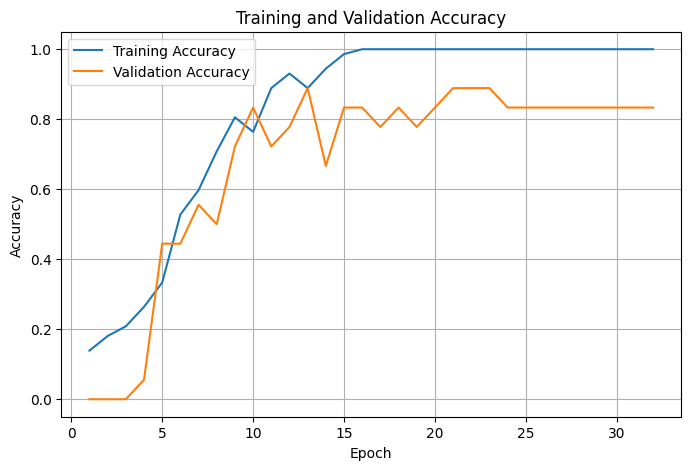

In [ ]:
# ======================================================
# STEP 15: PLOT TRAINING AND VALIDATION ACCURACY
# ======================================================

# Extract training and validation accuracy from history
train_accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]

# Create an epoch range for the x-axis
epochs_range = range(1, len(train_accuracy) + 1)

# Plot accuracy curves
plt.figure(figsize=(8, 5))
plt.plot(epochs_range, train_accuracy, label="Training Accuracy")
plt.plot(epochs_range, val_accuracy, label="Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

##5.2 Plot Training and Validation Loss

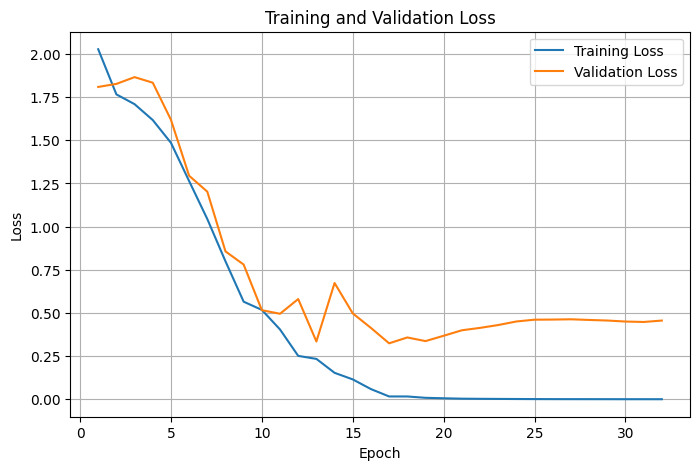

In [ ]:
# ======================================================
# STEP 16: PLOT TRAINING AND VALIDATION LOSS
# ======================================================

# Extract training and validation loss from history
train_loss = history.history["loss"]
val_loss = history.history["val_loss"]

# Plot loss curves
plt.figure(figsize=(8, 5))
plt.plot(epochs_range, train_loss, label="Training Loss")
plt.plot(epochs_range, val_loss, label="Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

##5.3 Evaluate the Model on Test Data
**Explanation**

The worksheet asks to evaluate the trained model on the test set and report test accuracy and loss.

In [ ]:
# ======================================================
# STEP 17: EVALUATE THE MODEL ON TEST DATA
# ======================================================

# Evaluate the trained model on unseen test data
test_loss, test_accuracy = model.evaluate(test_ds)

# Print the results
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.6000 - loss: 1.7375
Test Loss: 1.7375
Test Accuracy: 0.6000


#Task 6: Save and Load the Model
##6.1 Save the Trained Model
**Explanation**

The worksheet specifically asks to save the trained model as an .h5 file.

In [ ]:
# ======================================================
# STEP 18: SAVE THE TRAINED MODEL
# ======================================================

# Save the final trained model in H5 format
model.save("final_fruit_cnn_model.h5")

print("Model saved successfully as final_fruit_cnn_model.h5")

Model saved successfully as final_fruit_cnn_model.h5


##6.2 Load the Saved Model

In [ ]:
# ======================================================
# STEP 19: LOAD THE SAVED MODEL
# ======================================================

# Load the saved model from disk
loaded_model = tf.keras.models.load_model("final_fruit_cnn_model.h5")

print("Saved model loaded successfully.")

Saved model loaded successfully.


##6.3 Re-evaluate the Loaded Model

In [ ]:
# ======================================================
# STEP 20: RE-EVALUATE THE LOADED MODEL
# ======================================================

# Evaluate the loaded model to confirm it works correctly
loaded_test_loss, loaded_test_accuracy = loaded_model.evaluate(test_ds)

# Print the results
print(f"Loaded Model Test Loss: {loaded_test_loss:.4f}")
print(f"Loaded Model Test Accuracy: {loaded_test_accuracy:.4f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step - accuracy: 0.6000 - loss: 1.7375
Loaded Model Test Loss: 1.7375
Loaded Model Test Accuracy: 0.6000


#Task 7: Predictions and Classification Report
##7.1 Make Predictions on Test Images
**Explanation**

The worksheet asks to:

use model.predict()
convert probabilities to labels with np.argmax()
generate a classification report

In [ ]:
# ======================================================
# STEP 21: MAKE PREDICTIONS ON TEST DATA
# ======================================================

# Import NumPy
import numpy as np

# Lists to store true labels and predicted labels
y_true = []
y_pred = []

# Loop through the test dataset batch by batch
for images, labels in test_ds:

    # Predict class probabilities for the current batch
    predictions = loaded_model.predict(images)

    # Convert probability distributions to class indices
    predicted_labels = np.argmax(predictions, axis=1)

    # Store the actual labels
    y_true.extend(labels.numpy())

    # Store the predicted labels
    y_pred.extend(predicted_labels)

# Convert lists to NumPy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Print first few values for checking
print("Actual labels   :", y_true[:10])
print("Predicted labels:", y_pred[:10])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 260ms/step
Actual labels   : [0 0 0 0 0 1 1 1 1 1]
Predicted labels: [2 2 0 0 0 2 2 2 2 1]


##7.2 Generate the Classification Report

In [ ]:
# ======================================================
# STEP 22: GENERATE CLASSIFICATION REPORT
# ======================================================

# Import classification_report from sklearn
from sklearn.metrics import classification_report

# Create the classification report
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names
)

# Display the report
print("Classification Report:\n")
print(report)

Classification Report:

              precision    recall  f1-score   support

        acai       0.75      0.60      0.67         5
     cupuacu       1.00      0.20      0.33         5
    graviola       0.38      1.00      0.56         5
     guarana       1.00      0.60      0.75         5
     pupunha       0.71      1.00      0.83         5
      tucuma       0.50      0.20      0.29         5

    accuracy                           0.60        30
   macro avg       0.72      0.60      0.57        30
weighted avg       0.72      0.60      0.57        30



##7.3 Display Sample Test Predictions
**Explanation**

This step is not strictly required by the worksheet, but it makes the notebook clearer and easier to understand.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step


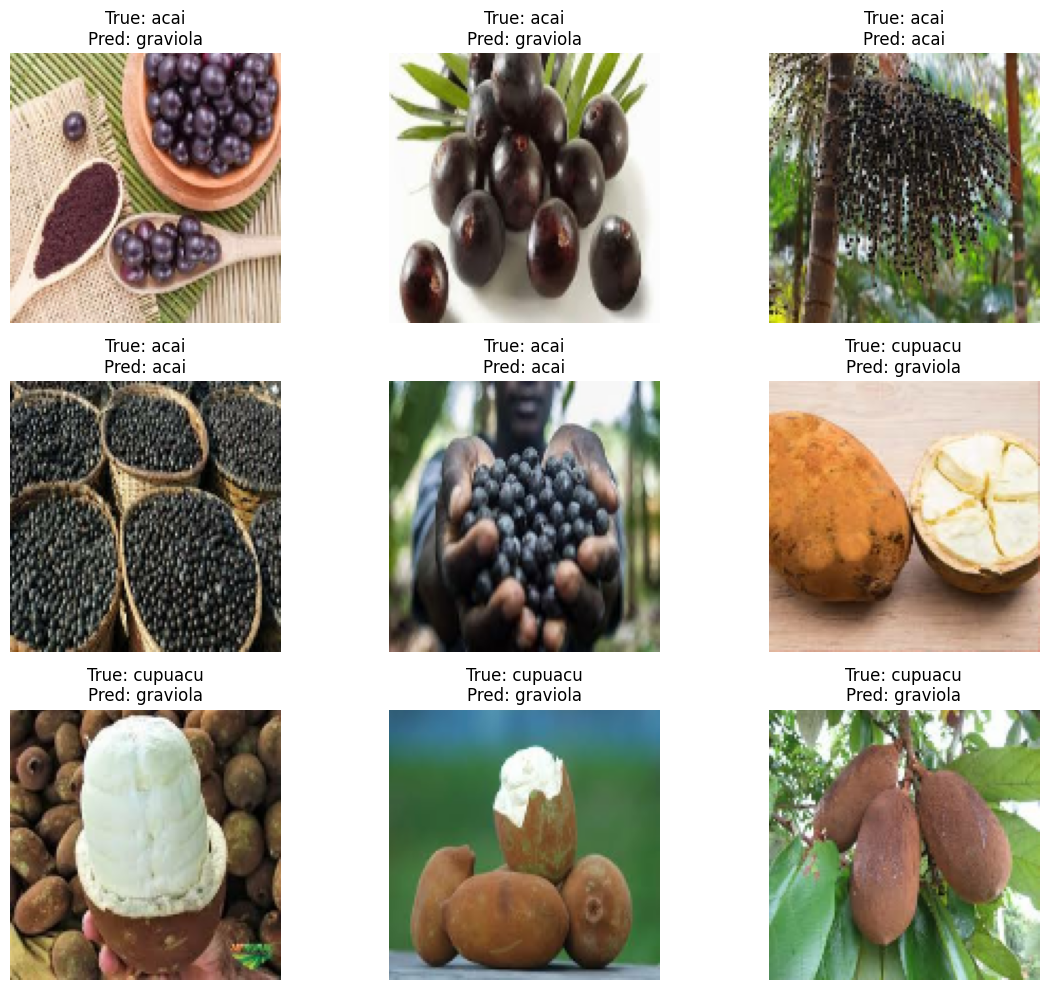

In [ ]:
# ======================================================
# STEP 23: DISPLAY SAMPLE TEST PREDICTIONS
# ======================================================

# Take one batch from test dataset
for images, labels in test_ds.take(1):

    # Predict classes for the current batch
    predictions = loaded_model.predict(images)
    predicted_labels = np.argmax(predictions, axis=1)

    # Create a figure for displaying predictions
    plt.figure(figsize=(12, 10))

    # Show up to 9 test images
    for i in range(min(9, len(images))):
        plt.subplot(3, 3, i + 1)

        # Display the image
        plt.imshow(images[i].numpy())

        # Get actual and predicted class names
        true_name = class_names[labels[i].numpy()]
        pred_name = class_names[predicted_labels[i]]

        # Display actual and predicted labels
        plt.title(f"True: {true_name}\nPred: {pred_name}")

        # Hide axis
        plt.axis("off")

    # Adjust subplot spacing and show the figure
    plt.tight_layout()
    plt.show()

# Conclusion:
*  In this worksheet, an end-to-end Convolutional Neural Network was implemented
*  for Amazon fruit image classification using TensorFlow and Keras.
* First, the dataset was extracted from a ZIP file and the class folders were loaded.
* Then, the images were visualized and checked for corruption.
#
*  After that, the dataset was loaded using image_dataset_from_directory(),
*  resized to 128x128, and normalized to the range [0, 1].
*  A CNN model was then built according to the architecture specified in the worksheet,
*  using two convolutional layers, two max pooling layers, a flatten layer,
*  two dense hidden layers, and a softmax output layer.
#
* The model was compiled using the Adam optimizer and trained using validation data,
*  ModelCheckpoint, and EarlyStopping.
*  Finally, the model was evaluated on the test dataset, saved as an H5 file,
*  loaded again, and used to generate predictions and a classification report.
#
*  This assignment demonstrates a complete image classification workflow
*  from data preparation to final evaluation.